<a href="https://colab.research.google.com/github/Alltingzrpozz/Alltingzrpozz/blob/main/Natural_Language_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries and Data Loader

In [2]:
import pandas as pd
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Download necessary NLTK resources
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve the LookupError

# Load datasets
df_train = pd.read_csv('/content/sample_data/train.csv')
df_test = pd.read_csv('/content/sample_data/test.csv')

print(f"Training rows: {len(df_train)}, Test rows: {len(df_test)}")

Training rows: 13240, Test rows: 460


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Data Exploration & Splitting

In [3]:
# Understanding the label distribution
print(df_train['label'].value_counts())

# 70/30 Split
X_train, X_val, y_train, y_val = train_test_split(
    df_train['tweet'],
    df_train['label'],
    test_size=0.3,
    random_state=100
)

label
NOT    8840
TIN    3876
UNT     524
Name: count, dtype: int64


# Data Preprocessing

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    # 1. Remove URLs and @User mentions (Noise Reduction)
    text = re.sub(r'http\S+|www\S+|@\w+', '', text)
    # 2. Lower-casing (Standardisation)
    text = text.lower()
    # 3. Remove non-ASCII characters (Emojis/Special symbols)
    text = text.encode('ascii', 'ignore').decode('ascii')
    # 4. Tokenisation & Lemmatisation (Linguistic Units)
    tokens = nltk.word_tokenize(text)
    # 5. Remove Stop Words (Focus on Signal)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and t.isalnum()]

    return " ".join(tokens)

# Apply cleaning to training and validation sets
X_train_clean = X_train.apply(clean_tweet)
X_val_clean = X_val.apply(clean_tweet)

# Feature Extraction

In [5]:
# Optimisation: Using unigrams and bigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000)

# Fit on training and transform both
X_train_tfidf = vectorizer.fit_transform(X_train_clean)
X_val_tfidf = vectorizer.transform(X_val_clean)

# Model Training and Evaluation

In [6]:
# Initialize and train the model
model = LinearSVC(random_state=100)
model.fit(X_train_tfidf, y_train)

# Predict on validation set
val_predictions = model.predict(X_val_tfidf)

# Critical Evaluation: Performance Report
print(classification_report(y_val, val_predictions))

              precision    recall  f1-score   support

         NOT       0.78      0.87      0.82      2638
         TIN       0.59      0.49      0.54      1177
         UNT       0.26      0.04      0.07       157

    accuracy                           0.73      3972
   macro avg       0.54      0.47      0.48      3972
weighted avg       0.70      0.73      0.71      3972



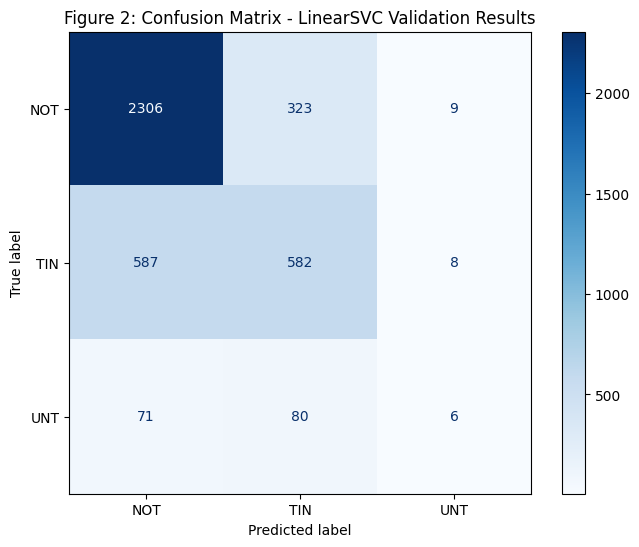

In [7]:


# 1. Generate the raw numbers for the matrix
cm = confusion_matrix(y_val, val_predictions, labels=['NOT', 'TIN', 'UNT'])

# 2. Create the visual plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NOT', 'TIN', 'UNT'])

# 3. Apply colours to the matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Figure 2: Confusion Matrix - LinearSVC Validation Results')
plt.show()

# Model Predictions

In [8]:
# 1. Preprocess the test data using the exact same function
df_test['clean_tweet'] = df_test['tweet'].apply(clean_tweet)

# 2. Convert to features using the SAME vectorizer (transform only)
X_test_tfidf = vectorizer.transform(df_test['clean_tweet'])

# 3. Make predictions using the best trained model
df_test['prediction'] = model.predict(X_test_tfidf)

# 4. View a sample of n=5 results for critical evaluation
print("Sample of 5 Predictions for Audit:")
display(df_test[['id', 'clean_tweet', 'prediction']].sample(5))

# 5. SAVE to CSV including the cleaned tweet column
df_test[['id', 'clean_tweet', 'prediction']].to_csv('test-predictions.csv', index=False)

print("\nSuccess: 'test-predictions.csv' created with id, clean_tweet, and prediction.")

Sample of 5 Predictions for Audit:


,id,clean_tweet,prediction
437,29008,conservative dumberthandogshit central point t...,NOT
319,23530,familiarwife crazy yes interested assistant ma...,NOT
352,18786,cnnisfakenews wonder rating suck cnnisajoke fa...,TIN
329,57732,repost theleadersmindset hola leader type read...,NOT
219,28744,hchottestceleb round 32 match 12 scarlett joha...,NOT



Success: 'test-predictions.csv' created with id, clean_tweet, and prediction.


# Pipeline Flowchart

Successfully generated! You can right-click the image below to save it:


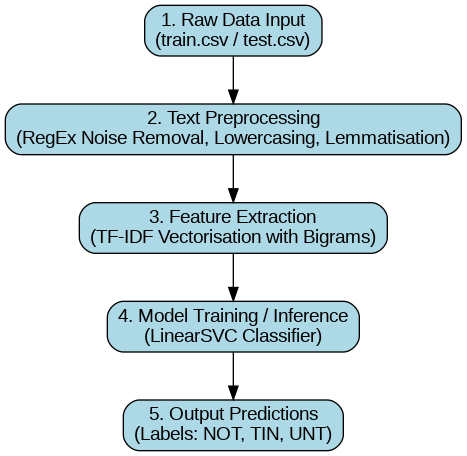

In [9]:
from graphviz import Digraph
from IPython.display import display, Image

# Create the flowchart object
pipeline = Digraph(comment='NLP Pipeline')
pipeline.attr(rankdir='TB', size='8,8') # TB means Top-to-Bottom
pipeline.node_attr.update(shape='box', style='rounded,filled', fillcolor='lightblue', fontname='Helvetica')

# Define the steps of pipeline
pipeline.node('A', '1. Raw Data Input\n(train.csv / test.csv)')
pipeline.node('B', '2. Text Preprocessing\n(RegEx Noise Removal, Lowercasing, Lemmatisation)')
pipeline.node('C', '3. Feature Extraction\n(TF-IDF Vectorisation with Bigrams)')
pipeline.node('D', '4. Model Training / Inference\n(LinearSVC Classifier)')
pipeline.node('E', '5. Output Predictions\n(Labels: NOT, TIN, UNT)')

# Connect the steps with arrows
pipeline.edges(['AB', 'BC', 'CD', 'DE'])

# Save the flowchart as a PNG image file
pipeline.render('nlp_pipeline_flowchart', format='png', cleanup=True)

# Display in Colab
print("Successfully generated! You can right-click the image below to save it:")
display(Image(filename='nlp_pipeline_flowchart.png'))